In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import seaborn as sns
sns.set_style('whitegrid')

import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd

from datetime import datetime
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)


In [2]:
df=pd.read_csv("Copy of sonar data.csv", encoding='latin1')

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

##### EDA #####

In [4]:
df.head(10)

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,0.1609,0.1582,0.2238,0.0645,0.0660,0.2273,0.3100,0.2999,0.5078,0.4797,0.5783,0.5071,0.4328,0.5550,0.6711,0.6415,0.7104,0.8080,0.6791,0.3857,0.1307,0.2604,0.5121,0.7547,0.8537,0.8507,0.6692,0.6097,0.4943,0.2744,0.0510,0.2834,0.2825,0.4256,0.2641,0.1386,0.1051,0.1343,0.0383,0.0324,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,0.4918,0.6552,0.6919,0.7797,0.7464,0.9444,1.0000,0.8874,0.8024,0.7818,0.5212,0.4052,0.3957,0.3914,0.3250,0.3200,0.3271,0.2767,0.4423,0.2028,0.3788,0.2947,0.1984,0.2341,0.1306,0.4182,0.3835,0.1057,0.1840,0.1970,0.1674,0.0583,0.1401,0.1628,0.0621,0.0203,0.0530,0.0742,0.0409,0.0061,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,0.6333,0.7060,0.5544,0.5320,0.6479,0.6931,0.6759,0.7551,0.8929,0.8619,0.7974,0.6737,0.4293,0.3648,0.5331,0.2413,0.5070,0.8533,0.6036,0.8514,0.8512,0.5045,0.1862,0.2709,0.4232,0.3043,0.6116,0.6756,0.5375,0.4719,0.4647,0.2587,0.2129,0.2222,0.2111,0.0176,0.1348,0.0744,0.0130,0.0106,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,0.0881,0.1992,0.0184,0.2261,0.1729,0.2131,0.0693,0.2281,0.4060,0.3973,0.2741,0.3690,0.5556,0.4846,0.3140,0.5334,0.5256,0.2520,0.2090,0.3559,0.6260,0.7340,0.6120,0.3497,0.3953,0.3012,0.5408,0.8814,0.9857,0.9167,0.6121,0.5006,0.3210,0.3202,0.4295,0.3654,0.2655,0.1576,0.0681,0.0294,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,0.4152,0.3952,0.4256,0.4135,0.4528,0.5326,0.7306,0.6193,0.2032,0.4636,0.4148,0.4292,0.5730,0.5399,0.3161,0.2285,0.6995,1.0000,0.7262,0.4724,0.5103,0.5459,0.2881,0.0981,0.1951,0.4181,0.4604,0.3217,0.2828,0.2430,0.1979,0.2444,0.1847,0.0841,0.0692,0.0528,0.0357,0.0085,0.0230,0.0046,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,0.2988,0.4250,0.6343,0.8198,1.0000,0.9988,0.9508,0.9025,0.7234,0.5122,0.2074,0.3985,0.5890,0.2872,0.2043,0.5782,0.5389,0.3750,0.3411,0.5067,0.5580,0.4778,0.3299,0.2198,0.1407,0.2856,0.3807,0.4158,0.4054,0.3296,0.2707,0.2650,0.0723,0.1238,0.1192,0.1089,0.0623,0.0494,0.0264,0.0081,0.0104,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R
5,0.0317,0.0956,0.1321,0.1408,0.1674,0.1710,0.0731,0.1401,0.2083,0.3513,0.1786,0.0658,0.0513,0.3752,0.5419,0.5440,0.5150,0.4262,0.2024,0.4233,0.7723,0.9735,0.9390,0.5559,0.5268,0.6826,0.5713,0.5429,0.2177,0.2149,0.5811,0.6323,0.2965,0.1873,0.2969,0.5163,0.6153,0.4283,0.5479,0.6133,0.5017,0.2377,0.1957,0.1749,0.1304,0.0597,0.1124,0.1047,0.0507,0.0159,0.0195,0.0201,0.0248,0.0131,0.0070,0.0138,0.0092,0.0143,0.0036,0.0103,R
6,0.0519,0.0548,0.0842,0.0319,0.1158,0.0922,0.1027,0.0613,0.1465,0.2838,0.2802,0.3086,0.2657,0.3801,0.5626,0.4376,0.2617,0.1199,0.6676,0.9402,0.7832,0.5352,0.6809,0.9174,0.7613,0.8220,0.8872,0.6091,0.2967,0.1103,0.1318,0.0624,0.0990,0.4006,0.3666,0.1050,0.1915,0.3930,0.4288,0.2546,0.1151,0.2196,0.1879,0.1437,0.2146,0.2360,0.1125,0.0254,0.0285,0.0178,0.0052,0.0081,0.0120,0.0045,0.0121,0.0097,0.0085,0.0047,0.0048,0.0053,R
7,0.0223,0.0375,0.0484,0.0475,0.0647,0.0591,0.0753,0.0098,0.0684,0.1487,0.1156,0.1654,0.3833,0.3598,0.1713,0.1136,0.0349,0.3796,0.7401,0.9925,0.9802,0.8890,0.6712,0.4286,0.3374,0.7366,0.9611,0.7353,0.4856,0.1594,0.3007,0.4096,0.3170,0.3305,0.3408,0.2186,0.2463,0.2726,0.1680,0.2792,0.2558,0.1740,0.2121,0.1099,0.0985,0.1271,0.1459,0.1164,0.0777,0.0439,0.0061,0.0145,0.0128,0.0145,0.0058,0.0049,0.0065,0.0093,0.0059,0.0022,R
8,0.0164,0.0173,0.0347,0.0070,0.0187,0.0671,0.1056,0.0697,0.0962,0.0251,0.0801,0.1056,0.1266,0.0890,0.0198,0.1133,0.2826,0.3234,0.3238,0.4333,0.6068,0.7652,0.9203,0.9719,0.9207,0.7545,0

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0.0200  207 non-null    float64
 1   0.0371  207 non-null    float64
 2   0.0428  207 non-null    float64
 3   0.0207  207 non-null    float64
 4   0.0954  207 non-null    float64
 5   0.0986  207 non-null    float64
 6   0.1539  207 non-null    float64
 7   0.1601  207 non-null    float64
 8   0.3109  207 non-null    float64
 9   0.2111  207 non-null    float64
 10  0.1609  207 non-null    float64
 11  0.1582  207 non-null    float64
 12  0.2238  207 non-null    float64
 13  0.0645  207 non-null    float64
 14  0.0660  207 non-null    float64
 15  0.2273  207 non-null    float64
 16  0.3100  207 non-null    float64
 17  0.2999  207 non-null    float64
 18  0.5078  207 non-null    float64
 19  0.4797  207 non-null    float64
 20  0.5783  207 non-null    float64
 21  0.5071  207 non-null    float64
 22  0.

In [6]:
df.shape

(207, 61)

In [7]:
df.describe()

,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,0.1609,0.1582,0.2238,0.0645,0.0660,0.2273,0.3100,0.2999,0.5078,0.4797,0.5783,0.5071,0.4328,0.5550,0.6711,0.6415,0.7104,0.8080,0.6791,0.3857,0.1307,0.2604,0.5121,0.7547,0.8537,0.8507,0.6692,0.6097,0.4943,0.2744,0.0510,0.2834,0.2825,0.4256,0.2641,0.1386,0.1051,0.1343,0.0383,0.0324,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
count,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000,207.000000
mean,0.029208,0.038443,0.043837,0.054053,0.075105,0.104599,0.121591,0.134677,0.177361,0.208245,0.236376,0.250666,0.273544,0.297689,0.321429,0.379217,0.416495,0.453055,0.504797,0.563449,0.609209,0.624841,0.648010,0.673223,0.675444,0.700148,0.702115,0.693473,0.641895,0.581871,0.506281,0.439903,0.416761,0.401535,0.390343,0.382597,0.362331,0.338353,0.324986,0.311385,0.290403,0.278269,0.246368,0.213053,0.196909,0.160738,0.122537,0.091217,0.051995,0.020366,0.016034,0.013472,0.010729,0.010917,0.009300,0.008181,0.007771,0.007947,0.007936,0.006523
std,0.023038,0.033040,0.038521,0.046583,0.055669,0.059247,0.061897,0.085340,0.118311,0.134741,0.132923,0.140264,0.141262,0.164075,0.205158,0.232975,0.264213,0.261947,0.258614,0.263225,0.258434,0.256373,0.250335,0.239555,0.245520,0.237768,0.246252,0.237631,0.240818,0.220864,0.212917,0.213389,0.206907,0.230499,0.257756,0.262755,0.239546,0.212655,0.199210,0.179076,0.170717,0.169137,0.139308,0.132795,0.151924,0.134254,0.087155,0.062496,0.036029,0.013673,0.012027,0.009628,0.007071,0.007310,0.007103,0.005719,0.005756,0.006485,0.006196,0.005038
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,0.028900,0.023600,0.018400,0.027300,0.003100,0.016200,0.034900,0.037500,0.049400,0.065600,0.051200,0.021900,0.056300,0.023900,0.024000,0.092100,0.048100,0.028400,0.014400,0.061300,0.048200,0.040400,0.047700,0.021200,0.022300,0.008000,0.035100,0.038300,0.037100,0.011700,0.036000,0.005600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013300,0.016400,0.018900,0.024450,0.037700,0.066950,0.080600,0.080350,0.096750,0.111150,0.128200,0.133450,0.165750,0.176100,0.166500,0.195900,0.205500,0.241950,0.299050,0.350450,0.397550,0.406350,0.455250,0.540450,0.524800,0.543550,0.529800,0.533950,0.461300,0.414250,0.349300,0.284100,0.257350,0.217550,0.178550,0.154000,0.160000,0.174250,0.172450,0.185900,0.164100,0.158700,0.155200,0.126850,0.094450,0.068400,0.064200,0.044950,0.026300,0.011500,0.008350,0.007350,0.005050,0.005350,0.004100,0.004400,0.003700,0.003600,0.003650,0.003100
50%,0.022800,0.030800,0.034200,0.044100,0.062000,0.092100,0.105600,0.111900,0.152200,0.181000,0.225100,0.249700,0.265500,0.281900,0.284000,0.307500,0.306800,0.370900,0.434800,0.543000,0.627500,0.667000,0.700700,0.701200,0.722100,0.754500,0.753900,0.731700,0.682500,0.607400,0.490600,0.430300,0.390300,0.349700,0.310800,0.319500,0.303900,0.310400,0.282900,0.279000,0.260500,0.244400,0.221100,0.177600,0.147300,0.121100,0.101500,0.077700,0.044900,0.017900,0.013800,0.011500,0.009600,0.009300,0.007500,0.006800,0.005900,0.005800,0.006300,0.005300
75%,0.035800,0.048100,0.058200,0.065700,0.101050,0.134150,0.153050,0.169800,0.231500,0.269000,0.301800,0.331600,0.351500,0.386950,0.453050,0.536050,0.660050,0.679100,0.731900,0.809450,0.818050

In [8]:
df.describe(include='object')

,R
count,207
unique,2
top,M
freq,111


In [9]:
# إحنا عارفين إن الداتا مفيهاش header
# فبنعمل أسماء للـ columns يدوياً
feature_cols = [f"F{i+1}" for i in range(60)]
df.columns = feature_cols + ["Label"]

In [10]:
df.head(10)

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28,F29,F30,F31,F32,F33,F34,F35,F36,F37,F38,F39,F40,F41,F42,F43,F44,F45,F46,F47,F48,F49,F50,F51,F52,F53,F54,F55,F56,F57,F58,F59,F60,Label
0,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,0.4918,0.6552,0.6919,0.7797,0.7464,0.9444,1.0000,0.8874,0.8024,0.7818,0.5212,0.4052,0.3957,0.3914,0.3250,0.3200,0.3271,0.2767,0.4423,0.2028,0.3788,0.2947,0.1984,0.2341,0.1306,0.4182,0.3835,0.1057,0.1840,0.1970,0.1674,0.0583,0.1401,0.1628,0.0621,0.0203,0.0530,0.0742,0.0409,0.0061,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
1,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,0.6333,0.7060,0.5544,0.5320,0.6479,0.6931,0.6759,0.7551,0.8929,0.8619,0.7974,0.6737,0.4293,0.3648,0.5331,0.2413,0.5070,0.8533,0.6036,0.8514,0.8512,0.5045,0.1862,0.2709,0.4232,0.3043,0.6116,0.6756,0.5375,0.4719,0.4647,0.2587,0.2129,0.2222,0.2111,0.0176,0.1348,0.0744,0.0130,0.0106,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
2,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,0.0881,0.1992,0.0184,0.2261,0.1729,0.2131,0.0693,0.2281,0.4060,0.3973,0.2741,0.3690,0.5556,0.4846,0.3140,0.5334,0.5256,0.2520,0.2090,0.3559,0.6260,0.7340,0.6120,0.3497,0.3953,0.3012,0.5408,0.8814,0.9857,0.9167,0.6121,0.5006,0.3210,0.3202,0.4295,0.3654,0.2655,0.1576,0.0681,0.0294,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
3,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,0.4152,0.3952,0.4256,0.4135,0.4528,0.5326,0.7306,0.6193,0.2032,0.4636,0.4148,0.4292,0.5730,0.5399,0.3161,0.2285,0.6995,1.0000,0.7262,0.4724,0.5103,0.5459,0.2881,0.0981,0.1951,0.4181,0.4604,0.3217,0.2828,0.2430,0.1979,0.2444,0.1847,0.0841,0.0692,0.0528,0.0357,0.0085,0.0230,0.0046,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
4,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,0.2988,0.4250,0.6343,0.8198,1.0000,0.9988,0.9508,0.9025,0.7234,0.5122,0.2074,0.3985,0.5890,0.2872,0.2043,0.5782,0.5389,0.3750,0.3411,0.5067,0.5580,0.4778,0.3299,0.2198,0.1407,0.2856,0.3807,0.4158,0.4054,0.3296,0.2707,0.2650,0.0723,0.1238,0.1192,0.1089,0.0623,0.0494,0.0264,0.0081,0.0104,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062,R
5,0.0317,0.0956,0.1321,0.1408,0.1674,0.1710,0.0731,0.1401,0.2083,0.3513,0.1786,0.0658,0.0513,0.3752,0.5419,0.5440,0.5150,0.4262,0.2024,0.4233,0.7723,0.9735,0.9390,0.5559,0.5268,0.6826,0.5713,0.5429,0.2177,0.2149,0.5811,0.6323,0.2965,0.1873,0.2969,0.5163,0.6153,0.4283,0.5479,0.6133,0.5017,0.2377,0.1957,0.1749,0.1304,0.0597,0.1124,0.1047,0.0507,0.0159,0.0195,0.0201,0.0248,0.0131,0.0070,0.0138,0.0092,0.0143,0.0036,0.0103,R
6,0.0519,0.0548,0.0842,0.0319,0.1158,0.0922,0.1027,0.0613,0.1465,0.2838,0.2802,0.3086,0.2657,0.3801,0.5626,0.4376,0.2617,0.1199,0.6676,0.9402,0.7832,0.5352,0.6809,0.9174,0.7613,0.8220,0.8872,0.6091,0.2967,0.1103,0.1318,0.0624,0.0990,0.4006,0.3666,0.1050,0.1915,0.3930,0.4288,0.2546,0.1151,0.2196,0.1879,0.1437,0.2146,0.2360,0.1125,0.0254,0.0285,0.0178,0.0052,0.0081,0.0120,0.0045,0.0121,0.0097,0.0085,0.0047,0.0048,0.0053,R
7,0.0223,0.0375,0.0484,0.0475,0.0647,0.0591,0.0753,0.0098,0.0684,0.1487,0.1156,0.1654,0.3833,0.3598,0.1713,0.1136,0.0349,0.3796,0.7401,0.9925,0.9802,0.8890,0.6712,0.4286,0.3374,0.7366,0.9611,0.7353,0.4856,0.1594,0.3007,0.4096,0.3170,0.3305,0.3408,0.2186,0.2463,0.2726,0.1680,0.2792,0.2558,0.1740,0.2121,0.1099,0.0985,0.1271,0.1459,0.1164,0.0777,0.0439,0.0061,0.0145,0.0128,0.0145,0.0058,0.0049,0.0065,0.0093,0.0059,0.0022,R
8,0.0164,0.0173,0.0347,0.0070,0.0187,0.0671,0.1056,0.0697,0.0962,0.0251,0.0801,0.1056,0.1266,0.0890,0.0198,0.1133,0.2826,0.3234,0.3238,0.4333,0.6068,0.7652,0.9203,0.9719,0.9207,0.7545,0.8289,0.8907,0.7309,0.6896,0.5829,0.4935,0.3101,0.0306,0.0244,0.1108,0.1594,0.1371,0.0696,0.0452,0.0620,0.1421,0.1597,0.1384,0.0372,0.0688,0.0867,0.0513,0.0092,0.0198,0.0118,0.0090,0.02

In [11]:
df.isnull().sum().sum()

np.int64(0)

In [12]:
df["Label"].value_counts()

Label
M    111
R     96
Name: count, dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

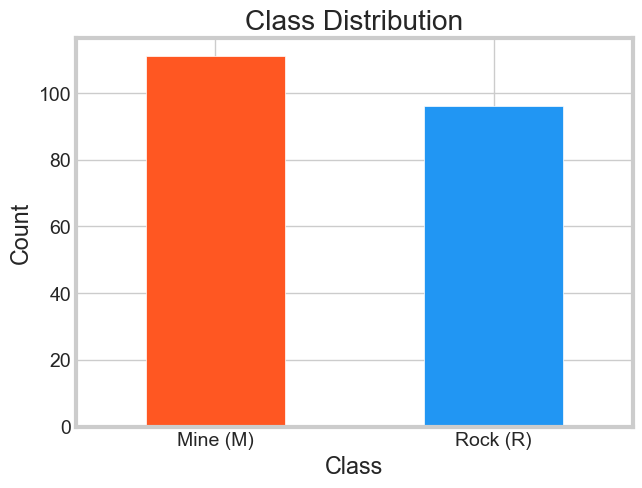

In [17]:
# توزيع الكلاسات بصرياً
df["Label"].value_counts().plot(kind="bar", color=["#FF5722", "#2196F3"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(ticks=[0,1], labels=["Mine (M)", "Rock (R)"], rotation=0)
plt.show()

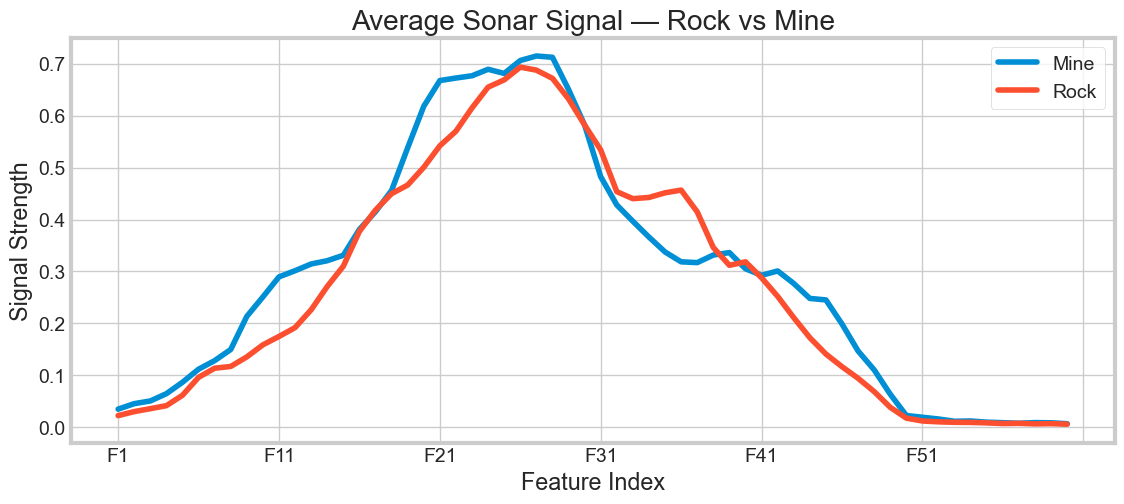

In [18]:
# متوسط الـ signal لكل كلاس
df.groupby("Label")[feature_cols].mean().T.plot(figsize=(12, 5))
plt.title("Average Sonar Signal — Rock vs Mine")
plt.xlabel("Feature Index")
plt.ylabel("Signal Strength")
plt.legend(["Mine", "Rock"])
plt.show()

In [19]:
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
F1,207.0,0.029208,0.023038,0.0015,0.01330,0.0228,0.03580,0.1371
F2,207.0,0.038443,0.033040,0.0006,0.01640,0.0308,0.04810,0.2339
F3,207.0,0.043837,0.038521,0.0015,0.01890,0.0342,0.05820,0.3059
F4,207.0,0.054053,0.046583,0.0058,0.02445,0.0441,0.06570,0.4264
F5,207.0,0.075105,0.055669,0.0067,0.03770,0.0620,0.10105,0.4010
F6,207.0,0.104599,0.059247,0.0102,0.06695,0.0921,0.13415,0.3823
F7,207.0,0.121591,0.061897,0.0033,0.08060,0.1056,0.15305,0.3729
F8,207.0,0.134677,0.085340,0.0055,0.08035,0.1119,0.16980,0.4590
F9,207.0,0.177361,0.118311,0.0075,0.09675,0.1522,0.23150,0.6828
F10,207.0,0.208245,0.134741,0.0113,0.11115,0.1810,0.26900,0.7106


In [22]:
X = df.drop(columns=['Label'])
y = df['Label']

In [23]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (207, 60)
y shape: (207,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
print("Train size:", X_train.shape[0])  # 166
print("Test size:",  X_test.shape[0])   # 42

Train size: 165
Test size: 42


In [25]:
le = LabelEncoder()
le.fit_transform(df["Label"])

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0])

In [26]:
# 4. Feature Scaling
scaler = StandardScaler()
scaler.fit_transform(X_train)  
scaler.transform(X_test)    

array([[-0.48399511, -0.74300166, -1.24800931, ..., -0.46710619,
         0.16755848,  0.39658414],
       [-0.78120425, -0.73021634, -0.91665032, ..., -0.63236891,
        -0.13802374, -0.46571022],
       [ 1.0380759 ,  0.54192339,  1.2100719 , ..., -0.48213008,
        -0.49185577, -0.23053903],
       ...,
       [ 1.05158541,  0.18713065, -0.78410673, ...,  0.88504331,
        -0.02544082, -0.66168621],
       [ 1.08761076,  1.61908693,  4.68934126, ...,  1.00523438,
         0.89130583, -0.17174623],
       [-0.36240956, -0.61514843, -0.9317121 , ..., -0.90279881,
        -0.4757725 , -0.818467  ]])

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# تعريف الموديلات
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":                  SVC(kernel="rbf", probability=True, random_state=42),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=100, random_state=42),
}

In [31]:
# Cross Validation — 5 Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

print("📊 Cross-Validation Results (5-Fold):")
print("-" * 45)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"  {name:<25} {scores.mean():.4f} ± {scores.std():.4f}")



📊 Cross-Validation Results (5-Fold):
---------------------------------------------
  Logistic Regression       0.8000 ± 0.0732
  Random Forest             0.8364 ± 0.0804
  SVM                       0.8000 ± 0.0827
  Gradient Boosting         0.8303 ± 0.0528


In [34]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_train_var = selector.fit_transform(X_train)
X_test_var  = selector.transform(X_test)

kept = selector.get_support()
print(f"Features قبل : {X_train.shape[1]}")
print(f"Features بعد : {X_train_var.shape[1]}")
print(f"اتحذف        : {X_train.shape[1] - X_train_var.shape[1]}")

Features قبل : 60
Features بعد : 38
اتحذف        : 22


In [37]:
from sklearn.feature_selection import SelectKBest, f_classif

selector_kbest = SelectKBest(score_func=f_classif, k=40)
X_train_kbest = selector_kbest.fit_transform(X_train, y_train)
X_test_kbest  = selector_kbest.transform(X_test)

# أعلى الـ features
scores = pd.Series(selector_kbest.scores_)
top_features = scores.nlargest(40)

print("Top 10 Features:")
print(top_features.head(10))

Top 10 Features:
10    29.133444
11    24.733980
44    24.535013
48    22.786743
47    21.450402
45    20.507367
43    20.359979
46    18.096132
9     16.223897
42    16.090950
dtype: float64


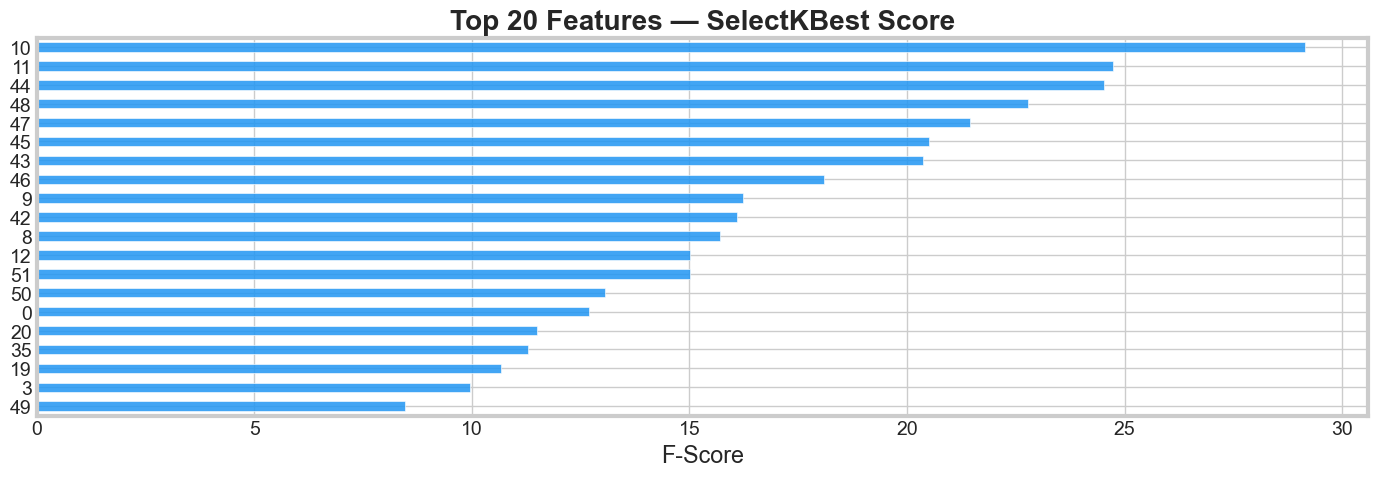

In [38]:
# بصرياً — أهمية كل feature
plt.figure(figsize=(14, 5))
top_features.head(20).sort_values().plot(kind="barh", color="#2196F3", alpha=0.85)
plt.title("Top 20 Features — SelectKBest Score", fontweight="bold")
plt.xlabel("F-Score")
plt.tight_layout()
plt.show()

In [40]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

datasets = {
    "All Features (68)":      (X_train,    X_test),
    "Variance Filter":        (X_train_var,   X_test_var),
    "SelectKBest (40)":       (X_train_kbest, X_test_kbest),
}

print("📊 Feature Selection Comparison:")
print("-" * 45)
for name, (X_tr, X_te) in datasets.items():
    scores = cross_val_score(rf, X_tr, y_train, cv=cv, scoring="accuracy")
    print(f"  {name:<25} {scores.mean():.4f} ± {scores.std():.4f}")

📊 Feature Selection Comparison:
---------------------------------------------
  All Features (68)         0.8364 ± 0.0804
  Variance Filter           0.8364 ± 0.0680
  SelectKBest (40)          0.8303 ± 0.0988


In [41]:
# بعد ما تشوف النتايج، بنحدد الـ features اللي هنكمل بيها
# مثلاً لو SelectKBest أحسن:
X_train_final = X_train_kbest
X_test_final  = X_test_kbest

print(f"✅ Final Feature Count: {X_train_final.shape[1]}")

✅ Final Feature Count: 40


In [42]:
RandomForestClassifier(n_estimators=100, max_depth=5)

,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
from sklearn.model_selection import GridSearchCV

# مثال بسيط على Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],   # عدد الأشجار
    "max_depth":    [None, 5, 10],    # عمق الشجرة
}

# ده معناه هيجرب 3 × 3 = 9 combinations

In [46]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_lr = {
    "C":        [0.01, 0.1, 1, 10, 100],  # قوة الـ regularization
    "solver":   ["lbfgs", "liblinear"],    # طريقة الحل
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,          # يستخدم كل الـ CPU cores
    verbose=1           # يوريك اللي بيحصل
)

grid_lr.fit(X_train_final, y_train)

print("✅ Best Params:", grid_lr.best_params_)
print("✅ Best CV Score:", round(grid_lr.best_score_, 4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
✅ Best Params: {'C': 1, 'solver': 'liblinear'}
✅ Best CV Score: 0.8061


In [47]:
param_grid_rf = {
    "n_estimators":      [100, 200, 300],   # عدد الأشجار
    "max_depth":         [None, 10, 20],    # عمق كل شجرة
    "min_samples_split": [2, 5, 10],        # أقل عدد samples عشان تتقسم
    "max_features":      ["sqrt", "log2"],  # عدد الـ features في كل split
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_final, y_train)

print("✅ Best Params:", grid_rf.best_params_)
print("✅ Best CV Score:", round(grid_rf.best_score_, 4))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
✅ Best Params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
✅ Best CV Score: 0.8303


In [48]:
param_grid_svm = {
    "C":      [0.1, 1, 10, 100],          # قوة الـ regularization
    "gamma":  ["scale", "auto", 0.001, 0.01],  # حجم تأثير كل نقطة
    "kernel": ["rbf", "poly"],             # شكل الـ decision boundary
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train_final, y_train)

print("✅ Best Params:", grid_svm.best_params_)
print("✅ Best CV Score:", round(grid_svm.best_score_, 4))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
✅ Best Params: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
✅ Best CV Score: 0.8242


In [49]:
param_grid_gb = {
    "n_estimators":  [100, 200],        # عدد الـ trees
    "learning_rate": [0.01, 0.1, 0.2], # سرعة التعلم
    "max_depth":     [3, 5, 7],         # عمق كل tree
    "subsample":     [0.8, 1.0],        # نسبة الداتا في كل tree
}

grid_gb = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train_final, y_train)

print("✅ Best Params:", grid_gb.best_params_)
print("✅ Best CV Score:", round(grid_gb.best_score_, 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
✅ Best CV Score: 0.8545


In [50]:
# هنشيل الـ best model
best_model = grid_gb.best_estimator_
print("✅ Best Model:", best_model)

✅ Best Model: GradientBoostingClassifier(max_depth=5, n_estimators=200, random_state=42,
                           subsample=0.8)


In [51]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred = best_model.predict(X_test_final)

# Accuracy
print("✅ Test Accuracy:", round(accuracy_score(y_test, y_pred), 4))

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Mine (M)", "Rock (R)"]))

✅ Test Accuracy: 0.8571

📊 Classification Report:
              precision    recall  f1-score   support

    Mine (M)       0.81      0.96      0.88        23
    Rock (R)       0.93      0.74      0.82        19

    accuracy                           0.86        42
   macro avg       0.87      0.85      0.85        42
weighted avg       0.87      0.86      0.85        42



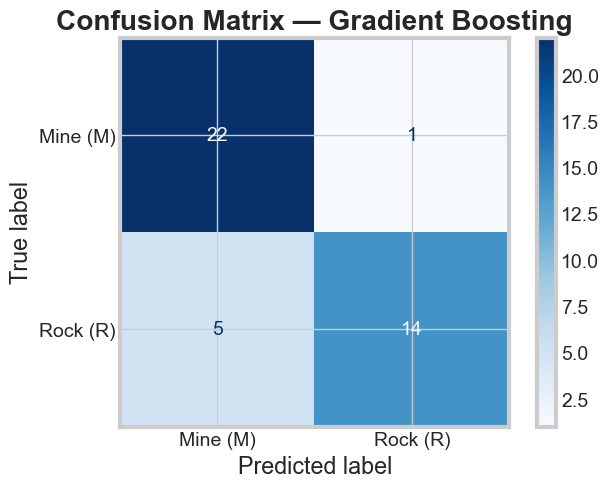

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=["Mine (M)", "Rock (R)"])

disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Gradient Boosting", fontweight="bold")
plt.show()

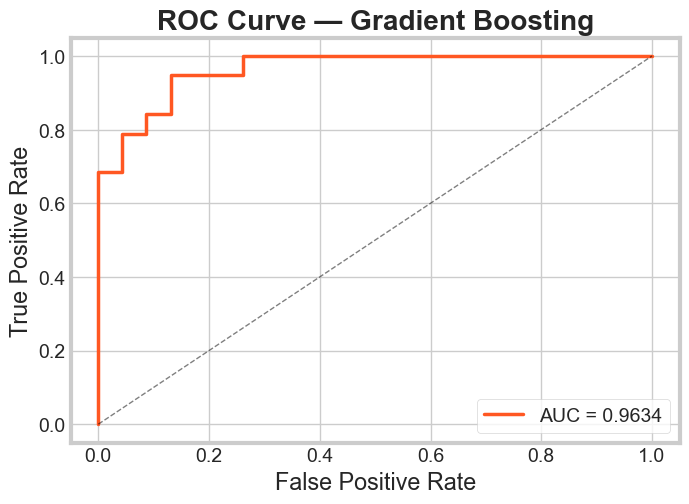

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

# تحويل y_test لأرقام
y_test_encoded = (y_test == "R").astype(int)  # R=1, M=0

y_prob = best_model.predict_proba(X_test_final)[:, 1]
fpr, tpr, _ = roc_curve(y_test_encoded, y_prob)
auc = roc_auc_score(y_test_encoded, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="#FF5722", linewidth=2.5, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], "k--", linewidth=1, alpha=0.5)
plt.title("ROC Curve — Gradient Boosting", fontweight="bold")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [57]:
import joblib
import os

# عمل folder للموديل
os.makedirs("model", exist_ok=True)

# حفظ كل حاجة
joblib.dump(best_model, "model/gradient_boosting.pkl")  #الموديل نفسه
joblib.dump(scaler,     "model/scaler.pkl")   #عشان نعمل scale لأي داتا جديدة
joblib.dump(selector,   "model/selector.pkl")  #عشان نختار نفس الـ features
joblib.dump(le,         "model/label_encoder.pkl")  # عشان نحول الـ 0/1 لـ M/R

print("✅ تم حفظ:")
print("   - model/gradient_boosting.pkl")
print("   - model/scaler.pkl")
print("   - model/selector.pkl")
print("   - model/label_encoder.pkl")

✅ تم حفظ:
   - model/gradient_boosting.pkl
   - model/scaler.pkl
   - model/selector.pkl
   - model/label_encoder.pkl


In [80]:
# 1. Feature Engineering
df["mean"]     = df[feature_cols].mean(axis=1)
df["std"]      = df[feature_cols].std(axis=1)
df["max"]      = df[feature_cols].max(axis=1)
df["min"]      = df[feature_cols].min(axis=1)
df["range"]    = df["max"] - df["min"]
df["energy"]   = (df[feature_cols] ** 2).sum(axis=1)
df["skewness"] = df[feature_cols].skew(axis=1)
df["kurtosis"] = df[feature_cols].kurt(axis=1)

new_features = ["mean","std","max","min","range","energy","skewness","kurtosis"]
all_features = feature_cols + new_features  # 68

In [82]:
# 2. Split
X = df[all_features].values
y = df["Label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [83]:
# 3. Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 4. Selector
selector = VarianceThreshold(threshold=0.01)
X_train_final = selector.fit_transform(X_train_sc)
X_test_final  = selector.transform(X_test_sc)

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape:", X_test_final.shape)

X_train_final shape: (165, 68)
X_test_final shape: (42, 68)


In [84]:
# 5. Train
best_model = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=200,
    subsample=0.8,
    random_state=42
)
best_model.fit(X_train_final, y_train)

# 6. تأكد
print("موديل بيتوقع:", best_model.n_features_in_, "feature")
print("Selector يختار:", selector.get_support().sum(), "feature")

موديل بيتوقع: 68 feature
Selector يختار: 68 feature


In [85]:
# 7. حفظ
joblib.dump(best_model, "model/gradient_boosting.pkl")
joblib.dump(scaler,     "model/scaler.pkl")
joblib.dump(selector,   "model/selector.pkl")

print("✅ كل حاجة اتحفظت صح!")

✅ كل حاجة اتحفظت صح!


In [86]:
# تأكد من الـ prediction
sample_original = X_test[0].reshape(1, -1)
sample_scaled   = scaler.transform(sample_original)
sample_selected = selector.transform(sample_scaled)
prediction      = best_model.predict(sample_selected)
probability     = best_model.predict_proba(sample_selected)

print("✅ Prediction شغالة صح!")
print(f"   النتيجة  : {'Mine 💣' if prediction[0] == 0 else 'Rock 🪨'}")
print(f"   Mine prob: {probability[0][0]:.2%}")
print(f"   Rock prob: {probability[0][1]:.2%}")

✅ Prediction شغالة صح!
   النتيجة  : Rock 🪨
   Mine prob: 0.33%
   Rock prob: 99.67%


##### Deployment#####

In [87]:
pip install streamlit

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.1 MB 3.6 MB/s eta 0:00:03
   ---- ----------------------------------- 1.0/9.1 MB 4.3 MB/s eta 0:00:02
   ----------- ---------------------------- 2.6/9.1 MB 4.6 MB/s eta 0:00:02
   --------------- ------------------------ 3.4/9.1 MB 4.6 MB/s eta 0:00:02
   ------------------- -------------------- 4.5/9.1 MB 4.7 MB/s eta 0:00:01
   ------------------------ --------------- 5.5/9.1 MB 4.7 MB/s eta 0:00:01
   --------------------------- ------------ 6.3/9.1 MB 4.7 MB/s eta 0:00:01
   -------------------------------- ------- 7.3/9.1 MB 4.7 MB/s eta 0:00:01
   ------------------------------------ --- 8.4/9.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------- 9.1/9.1 MB 4.6 MB/s  0:00:02
   ---------------------------------------- 0.0/795.4 kB ? eta -:--:--
   ---------------------------------------- 795.4/795.4 kB 4.2 MB/s  0:00:00
   -----------------------

In [88]:
cd "C:\Users\tarek\Desktop\project meta motion\Rock&&Mine"

C:\Users\tarek\Desktop\project meta motion\Rock&&Mine


In [89]:
streamlit run app.py

SyntaxError: invalid syntax (3737097518.py, line 1)